# **RETAIL STORE SALES**

## **Import Library**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
from sklearn.impute import KNNImputer

# **Business Understanding**

## **Business Objective**

[Analisis Retail Store Sales]

Analisis pada dataset **Retail Store Sales** bertujuan untuk membantu manajemen dalam memahami, mengevaluasi, serta mengoptimalkan kinerja penjualan dan strategi operasional toko ritel secara menyeluruh. Dataset ini memuat 12.575 data transaksi dengan berbagai variabel penting seperti *Transaction ID, Customer ID, Category, Item, Price Per Unit, Quantity, Total Spent, Payment Method, Location, Transaction Date,* serta *Discount Applied*.

Hasil analisis ini diharapkan mampu menjadi dasar pengambilan keputusan strategis dalam pengelolaan stok, penetapan harga, optimalisasi promosi, serta peningkatan profitabilitas dan efisiensi operasional toko ritel secara keseluruhan.

Dataset ini menggambarkan perilaku belanja pelanggan dalam sebuah toko ritel, baik dari sisi produk, nilai transaksi, hingga cara pembayaran.

**Studi Kasus**

Sebuah perusahaan ritel ingin meningkatkan pendapatan dan memahami pola belanja pelanggan. Mereka mengumpulkan data transaksi untuk dianalisis agar tahu:

* Produk apa paling laku

* Kapan penjualan tinggi atau rendah

* Apakah diskon efektif

* Metode pembayaran favorit pelanggan



## **Assess Situation**

Situasi analisis pada dataset Penjualan Toko Ritel didasarkan pada kondisi data yang terdiri dari 12.575 transaksi penjualan dalam bentuk data sintetis yang dirancang agar menyerupai kondisi penjualan di dunia nyata.  Dataset ini berisi 8 kategori produk, masing-masing dengan 25 item, dan harga yang tetap tidak berubah. Dengan demikian, anda bisa mengukur kinerja penjualan berdasarkan kategori atau item secara lebih rapi dan terorganisir.  Beragamnya variabel membuka kesempatan untuk menganalisis tren penjualan, pola tindakan pembeli, dan kontribusi terhadap pendapatan secara menyeluruh.  Adanya kolom waktu transaksi juga membantu dalam mengetahui pola penjualan yang terjadi sepanjang tahun dan bagaimana penjualan berubah dari waktu ke waktu.

Namun, dataset ini memang dibuat khusus untuk latihan membersihkan data, mengeksplorasi data (EDA), dan mengolah fitur, sehingga secara sengaja disajikan dalam kondisi yang belum bersih.  Tantangan terbesar yang dihadapi adalah adanya ketidaksamaan, kemungkinan nilai yang hilang, data yang berulang, atau format data yang berbeda-beda yang bisa mengganggu ketepatan hasil analisis.  Oleh karena itu, sebelum melanjutkan analisis, diperlukan proses membersihkan dan mempersiapkan data secara teratur agar kualitas data tetap terjaga.  Langkah ini penting agar insight yang diperoleh benar-benar mencerminkan situasi penjualan yang nyata dan bisa digunakan sebagai dasar dalam mengambil keputusan bisnis yang lebih tepat.

## **Analytic Goals & Project Plan**

**Tujuan**

Mengolah dataset ini adalah menganalisis data penjualan ritel untuk memahami pola penjualan dan  preferensi pelanggan terhadap produk dan metode pembayaran.

**Rencana**

* Memahami data dengan mengetahui tipe data dan memahami struktur kategori serta item produk

* Mengolah data dengan menangani data yang kosong dan memperbaiki data tidak konsisten.

* melakukan EDA dengan mencari kategori terlaris, melihat distribusi belanja, menganalisis metode pembayaran, dan mengamati tren penjualan.

* Membuat visualisasi data.

* Menarik kesimpulan dan rekomendasi untuk menentukan strategi promosi dan meningkatkan penjualan.

# **Data Understanding**

## **Memuat Dataset**

Sumber dataset ini berasal dari Retail Store Sales, yang bertujuan untuk  menganalisis data penjualan ritel sehingga anda dapat memahami pola penjualan dan  preferensi pelanggan terhadap produk dan metode pembayaran.

In [ ]:
file = "/content/drive/MyDrive/PRAKTIKUM AVD /retail_store_sales.csv"
df = pd.read_csv(file)

df

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
...,...,...,...,...,...,...,...,...,...,...,...
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True


In [ ]:
df.head(10)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
5,TXN_7482416,CUST_09,Patisserie,NaN,NaN,10.0,200.0,Credit Card,Online,2023-11-30,NaN
6,TXN_3652209,CUST_07,Food,Item_1_FOOD,5.0,8.0,40.0,Credit Card,In-store,2023-06-10,True
7,TXN_1372952,CUST_21,Furniture,NaN,33.5,NaN,NaN,Digital Wallet,In-store,2024-04-02,True
8,TXN_9728486,CUST_23,Furniture,Item_16_FUR,27.5,1.0,27.5,Credit Card,In-store,2023-04-26,False
9,TXN_2722661,CUST_25,Butchers,Item_22_BUT,36.5,3.0,109.5,Cash,Online,2024-03-14,False


In [ ]:
df.tail(10)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
12565,TXN_1712895,CUST_07,Computers and electric accessories,Item_2_CEA,6.5,5.0,32.5,Digital Wallet,In-store,2024-09-06,False
12566,TXN_6298574,CUST_01,Milk Products,Item_1_MILK,5.0,4.0,20.0,Cash,Online,2023-05-09,False
12567,TXN_4890318,CUST_25,Butchers,Item_3_BUT,8.0,5.0,40.0,Credit Card,In-store,2023-03-28,False
12568,TXN_1096134,CUST_06,Food,Item_4_FOOD,9.5,8.0,76.0,Digital Wallet,In-store,2022-06-11,NaN
12569,TXN_2318174,CUST_18,Patisserie,Item_1_PAT,5.0,9.0,45.0,Digital Wallet,In-store,2024-05-13,False
12570,TXN_9347481,CUST_18,Patisserie,Item_23_PAT,38.0,4.0,152.0,Credit Card,In-store,2023-09-03,NaN
12571,TXN_4009414,CUST_03,Beverages,Item_2_BEV,6.5,9.0,58.5,Cash,Online,2022-08-12,False
12572,TXN_5306010,CUST_11,Butchers,Item_7_BUT,14.0,10.0,140.0,Cash,Online,2024-08-24,NaN
12573,TXN_5167298,CUST_04,Furniture,Item_7_FUR,14.0,6.0,84.0,Cash,Online,2023-12-30,True
12574,TXN_2407494,CUST_23,Food,Item_9_FOOD,17.0,3.0,51.0,Cash,Online,2022-08-06,NaN


## **Deskripsi Data**

### **Informasi Dasar**

Tujuan dari Informasi Dasar adalah untuk mencari informasi awal atau dasar dari dataset ini.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


Berdasarkan data di atas, dapat diketahui bahwa dataset ini memiliki 12575 Baris dan 11 Kolom

### **Informasi Lanjutan**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


Berdasarkan data di atas, diperoleh informasi lanjutan sebagai berikut:

1. Transaction ID:
- Jumlah baris: 12575
- Tipe data   : object
- Deskripsi   : kode unik transaksi

2. Customer ID:
- Jumlah baris: 12575
- Tipe data   : object
- Deskripsi   : kode unik customer

3. Category:
- Jumlah baris: 12575
- Tipe data   : object
- Deskripsi   : digunakan untuk mengklasifikasikan kategori produk

4. Item:
- Jumlah baris: 11362
- Tipe data   : object
- Deskripsi   : kode untuk setiap item terdiri dari item ke berapa dan kategori dari item tersebut

5. Price Per Unit:
- Jumlah baris: 11966
- Tipe data   : float64
- Deskripsi   : harga per unit dari produk yang dibeli

6. Quantity:
- Jumlah baris: 11971
- Tipe data   : float64
- Deskripsi   : kuantitas dari produk yang dibeli oleh customer

7. Total Spent:
- Jumlah baris: 12575
- Tipe data   : float64
- Deskripsi   : biaya yang dikeluarkan oleh customer untuk membayar produk yang dibeli

8. Payment Method:
- Jumlah baris: 12575
- Tipe data   : object
- Deskripsi   : metode yang digunakan customer untuk membayar

9. Location:
- Jumlah baris: 12575
- Tipe data   : object
- Deskripsi   : lokasi dimana transaksi dilakukan

10. Transaction Date:
- Jumlah baris: 12575
- Tipe data   : object
- Deskripsi   : tanggal transaksi dilakukan

11. Discount Applied:
- Jumlah baris: 8376
- Tipe data   : object
- Deskripsi   : menjelaskan apakah customer mendapatkan diskon atau tidak


### **Informasi Statistik Deskriptif**

In [ ]:
df.describe(include='all')

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
count,12575,12575,12575,11362,11966.000000,11971.000000,11971.000000,12575,12575,12575,8376
unique,12575,25,8,200,NaN,NaN,NaN,3,2,1114,2
top,TXN_2407494,CUST_05,Electric household essentials,Item_2_BEV,NaN,NaN,NaN,Cash,Online,2022-05-30,True
freq,1,544,1591,126,NaN,NaN,NaN,4310,6354,26,4219
mean,NaN,NaN,NaN,NaN,23.365912,5.536380,129.652577,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,10.743519,2.857883,94.750697,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,5.000000,1.000000,5.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,14.000000,3.000000,51.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,23.000000,6.000000,108.500000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,33.500000,8.000000,192.000000,NaN,NaN,NaN,NaN


1. Count (Kelengkapan Data) berdasarkan data, total baris transaksi adalah 12575. Maka disini kita mendapatkan indormasi berupa:

- Data Item hilang 1213 data (12575 - 11362)
- Data Price Per Unit hilang 609 data (12575 - 11966)
- Data Quantity hilang 604 data (12575 - 11971)
- Data Total Spent hilang 604 data (12575 11971)
- Data Discount Applied hilang 4199 data (12575 - 8376)

Kesimpulan:
Kolom Item, Price Per Unit, Quantity, Total Spent, dan Discount Applied memiliki missing values atau kekosongan data. Kolom lainnya memiliki data yang lengkap yaitu 12575 data

================================================================================

2. Mean vs Median (Distribusi Data)
- Kolom Total Spent (Nilai Penjualan)
  - Mean = 2308,47
  - Median = 2245,30

Kesimpulan:

Nilai rata-rata sedikit lebih tinggi dibandingkan median, yang menunjukkan adanya beberapa transaksi dengan nilai pembelian sangat tinggi (outlier). Namun, selisihnya tidak terlalu ekstrem sehingga distribusi masih relatif mendekati simetris.

- Kolom Quantity (Kuantitas Pembelian)
  - Mean = 10,18
  - median = 6,00

Kesimpulan:

Perbedaan yang cukup jauh antara mean dan median menunjukkan adanya transaksi dengan jumlah pembelian besar yang menarik nilai rata-rata ke atas. Mayoritas pelanggan membeli dalam jumlah relatif kecil, tetapi terdapat beberapa transaksi dalam jumlah sangat besar.

================================================================================

3. Min dan Max (Validasi logika)
- Kolom Total Spent
  - Min = 8,50
  - Max = 8120,00

Kesimpulan:

Rentang nilai penjualan cukup lebar, yang wajar dalam bisnis retail dengan berbagai kategori produk dan volume pembelian yang beragam.

- Kolom Quantity
  - Min = 1
  - Max = 120

Kesimpulan:

Nilai maksimum yang sangat tinggi dalam satu transaksi perlu divalidasi lebih lanjut, kemungkinan merupakan pembelian dalam jumlah besar atau potensi kesalahan input data.

================================================================================

4. Standar Deviasi (Variabiltas Data)
- Kolom Total Spent
  - Mean = 2308,47
  - Standar = 1590,82

Kesimpulan:

Standar deviasi yang cukup besar menunjukkan variasi nilai transaksi yang tinggi antar pelanggan.

================================================================================

Kesimpulan Umum

1. Data menunjukkan distribusi condong ke kanan (right-skewed) pada hampir semua variabel utama.

2. Terdapat transaksi dalam jumlah besar yang memengaruhi rata-rata penjualan dan kuantitas.

3. Variabilitas profit sangat tinggi, menandakan stabilitas keuntungan belum merata di seluruh transaksi.

4. Diperlukan analisis lanjutan terhadap transaksi ekstrem (outliers), untuk memahami penyebab dan dampaknya terhadap kinerja bisnis.

## **VERIFIKASI KUALITAS DATA**

### **Data Type Check**

Tujuan Data Type Check adalah untuk mengecek apakah setiap kolom sudah sesuai dengan tipe datanya atau tidak, dan membuat visualisasi yang akan kita buat menjadi akurat.

In [ ]:
df.dtypes

,0
Transaction ID,object
Customer ID,object
Category,object
Item,object
Price Per Unit,float64
Quantity,float64
Total Spent,float64
Payment Method,object
Location,object
Transaction Date,object


Dari data di atas, kita mendapat informasi bahwa

1. Kolom Transaction Date seharusnya bertipe data datetime bukan object. Hal ini karena kolom tersebut menyimpan data yang seharunya numerik yaitu datetime bukan object. Walaupun didalam kolom ini datanya sudah numerik dan konsisten, namun perlu kita ubah ke datetime agar pada tahap analisis tren dan frekuensi, kolom ini dapat digunaka, bukan menjadi bar chart

2. Kolom Quantity harusnya bertipe data int64 bukan float64. Hal ini karena kuantitas atau jumlah barang tidak mungkin berjumlah desimal, karena dihitung per produk.

### **Inconsistent Values**

Pada tahap ini, tujuannya adalah untuk mengecek apakah dataset ini sudah konsisten atau ada inkonsistensi data, contohnya seperti dalam penulisan.

In [ ]:
print(df['Transaction ID'].unique())

['TXN_6867343' 'TXN_3731986' 'TXN_9303719' ... 'TXN_5306010' 'TXN_5167298'
 'TXN_2407494']


In [ ]:
print(df['Customer ID'].unique())

['CUST_09' 'CUST_22' 'CUST_02' 'CUST_06' 'CUST_05' 'CUST_07' 'CUST_21'
 'CUST_23' 'CUST_25' 'CUST_14' 'CUST_15' 'CUST_17' 'CUST_01' 'CUST_10'
 'CUST_04' 'CUST_13' 'CUST_18' 'CUST_08' 'CUST_20' 'CUST_12' 'CUST_11'
 'CUST_19' 'CUST_16' 'CUST_24' 'CUST_03']


In [ ]:
print(df['Category'].unique())

['Patisserie' 'Milk Products' 'Butchers' 'Beverages' 'Food' 'Furniture'
 'Electric household essentials' 'Computers and electric accessories']


In [ ]:
print(df['Item'].unique())

['Item_10_PAT' 'Item_17_MILK' 'Item_12_BUT' 'Item_16_BEV' 'Item_6_FOOD'
 nan 'Item_1_FOOD' 'Item_16_FUR' 'Item_22_BUT' 'Item_3_BUT' 'Item_2_FOOD'
 'Item_24_PAT' 'Item_16_MILK' 'Item_17_PAT' 'Item_13_EHE' 'Item_7_BEV'
 'Item_4_EHE' 'Item_10_FOOD' 'Item_14_FUR' 'Item_20_BUT' 'Item_25_FUR'
 'Item_14_FOOD' 'Item_22_PAT' 'Item_11_FOOD' 'Item_6_PAT' 'Item_21_EHE'
 'Item_25_BEV' 'Item_23_FOOD' 'Item_10_FUR' 'Item_11_BEV' 'Item_23_BUT'
 'Item_22_BEV' 'Item_10_EHE' 'Item_24_BUT' 'Item_8_BEV' 'Item_3_FOOD'
 'Item_12_FOOD' 'Item_16_CEA' 'Item_11_PAT' 'Item_16_BUT' 'Item_5_CEA'
 'Item_19_MILK' 'Item_23_FUR' 'Item_7_FUR' 'Item_15_CEA' 'Item_6_MILK'
 'Item_24_CEA' 'Item_22_CEA' 'Item_22_FOOD' 'Item_2_BUT' 'Item_14_PAT'
 'Item_12_PAT' 'Item_18_FOOD' 'Item_1_PAT' 'Item_4_BEV' 'Item_22_FUR'
 'Item_7_PAT' 'Item_20_CEA' 'Item_20_FOOD' 'Item_11_FUR' 'Item_25_PAT'
 'Item_7_FOOD' 'Item_21_FUR' 'Item_24_FUR' 'Item_8_MILK' 'Item_4_FOOD'
 'Item_14_BEV' 'Item_4_PAT' 'Item_4_MILK' 'Item_7_CEA' 'Item_6_EHE'
 'Ite

In [ ]:
print(df['Price Per Unit'].unique())

[18.5 29.  21.5 27.5 12.5  nan  5.  33.5 36.5  8.   6.5 39.5 24.5 23.
 35.  14.   9.5 41.  20.  38.  15.5 11.  32.  26.  30.5 17. ]


In [ ]:
print(df['Quantity'].unique())

[10.  9.  2.  7.  8. nan  1.  3.  6.  4.  5.]


In [ ]:
print(df['Total Spent'].unique())

[185.  261.   43.  247.5  87.5 200.   40.    nan  27.5 109.5  72.   52.
  45.5 237.   55.  232.  275.   23.  126.  105.   66.5  18.5  49.  134.
 410.  245.  182.5 100.  196.  315.  287.   76.   92.5 190.  255.5 276.5
  46.5   8.  107.5 165.   80.  192.5 335.   66.  215.   96.   42.   11.
 234.  316.   82.5 180.  365.   39.  172.  122.   30.   84.  320.  219.
  67.  146.  290.   70.  160.   82.   14.  355.5 124.   28.5  47.5 193.5
  38.   12.5 140.  120.  183.  305.   41.  155.   19.5  33.  108.5 119.
 280.   62.   32.  380.  304.  139.5 114.  192.  167.5  88.  395.  158.
  25.   50.   32.5  15.   33.5  24.  111.   46.   36.5  62.5 161.   26.
  98.   85.  228.   91.5  93.   35.  208.  100.5   9.5  10.  138.  288.
  60.  123.   73.  197.5  69.   61.  116.   55.5   6.5 152.5 118.5  74.
 205.  150.5 110.   19.   48.  175.  369.   37.5  65.  170.   77.5 129.5
  15.5  24.5 147.   21.5  31.   99.  128.   58.5 266.   29.  268.   64.
 115.   64.5 260.  207.  224.  328.   92.  244.   39.5  16.  

In [ ]:
print(df['Payment Method'].unique())

['Digital Wallet' 'Credit Card' 'Cash']


In [ ]:
print(df['Location'].unique())

['Online' 'In-store']


In [ ]:
print(df['Transaction Date'].unique())

['2024-04-08' '2023-07-23' '2022-10-05' ... '2023-03-17' '2024-02-29'
 '2022-09-16']


In [ ]:
print(df['Discount Applied'].unique())

[True False nan]


Setelah menganalisis dari seluruh kolom, tidak ditemukan inkonsistensi data pada dataset ini.

### **Missing Values**

Pada tahap ini, tujuannya adalah untuk melihat seberapa banyak data yang hilang pada seluruh kolom.

In [ ]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
Transaction ID,0.000000
Customer ID,0.000000
Category,0.000000
Item,9.646123
Price Per Unit,4.842942
Quantity,4.803181
Total Spent,4.803181
Payment Method,0.000000
Location,0.000000
Transaction Date,0.000000


Dari data di atas, kita mendapat informasi sebagai berikut:

1. Kolom Item memiliki missing values sekitar 9,6%.

2. Kolom Price Per Unit memiliki missing values sekitar 4,8%.

3. Kolom Discount Applied memiliki missing values sekitar 33,3%.

Kesimpulan:

Adanya missing values mengharuskan kita untuk meninindaklanjuti data ini yaitu dengan cara ditangani atau dihapus.

### **Duplicated Values**

Pada tahap ini, tujuannya adalah untuk mencari tahu apakah dataset ini memiiki data duplikat.

In [ ]:
df[df.duplicated()]

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied


Dari informasi diatas, dapat disimpulkan bahwa dataset ini tidak memiliki duplikasi data.

### **Outliers Values**

Pada tahap ini, tujuanya adalah untuk melihat nilai ekstrim (outliers) pada kolom bertipe data numerik. Hal ini dilakukan untuk mendapatkan insight yang akurat sehingga kedepannya analisis dan model yang kita akan bangun akurat.

In [ ]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
Price Per Unit,0.000000
Quantity,0.000000
Total Spent,0.477137


Dari informasi diatas, kita mendapatkan presentase berikut bahwa hanya kolom Sales yang memiliki outliers dengan presentase 0,4%.

# **Eksplorasi Data (EDA)**

## **Comparison/Perbandingan**

Aktivitas:
Membandingkan total spent (Sales) pada kedua lokasi, yaitu in-store dan online (Lokasi).

Tujuan:
Mengidentifikasi lokasi kegiatan transaksi mana yang memberikan kontribusi pendapatan terbesar.

Visualisasi:
Bar Chart (Grafik Batang).

In [ ]:
penjualan_market = df.groupby('Location')['Total Spent'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=penjualan_market.index, y=penjualan_market.values, palette='viridis', hue=penjualan_market.index, legend=False)
plt.title('Total Penjualan Berdasarkan Lokasi')
plt.xlabel('Lokasi')
plt.ylabel('Total Pendapatan')
plt.xticks(rotation=45)
plt.show()

Dari visualisasi data yang diberikan, kita mendapatkan informasi bahwa total penjualan pada lokasi online lebih tinggi walaupun selisihnya tidak begitu signifikan. Hal ini menunjukan bahwa pelayanan dan ketersediaan online harus dipertahankan dan perlu adanya promosi serta evaluasi pada lokasi in-store

## **Composition/Komposisi**

Aktivitas: Melihat presentase total penjualan berdasarkan kategori produk (Category).

Tujuan: Mengetahui kategori produk mana yang paling mendominasi penjualan toko ritel.

Visualisasi: Pie Chart (Grafik Lingkaran).

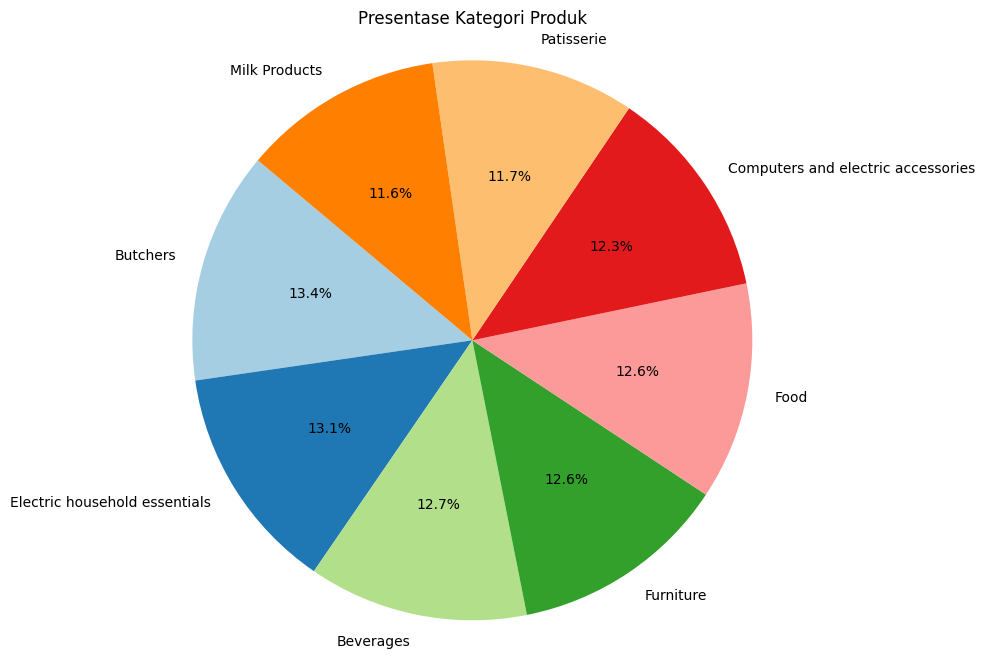

In [ ]:
sales_by_category = df.groupby('Category')['Total Spent'].sum().sort_values(ascending=False)


plt.figure(figsize=(10, 8))
sales_by_category.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Presentase Kategori Produk')
plt.ylabel('')
plt.axis('equal')
plt.show()

Dari visualisasi data yang diberikan, kategori Butchers mendominasi dari 8 kategori yang ada, hal ini perlu dipertahankan. Bagi kategori dibawahnya perlu adanya promosi  untuk meningkatkan penjualan dan evaluasi serta analisis mengenai kurangnya peminat pada kategori dengan presentase dibawah kategori Butchers.

## **Distribution/Dsitribusi**

Aktivitas: Menganalisi penyebaran nilai transaksi pada kolom Total Spent.

Tujuan: Melihat mayoritas transaksi bernilai besar atau kecil, serta mendeteksi adanya kecondongan (skewness) dalam data penjuakan.

Visualisasi: Histogram.

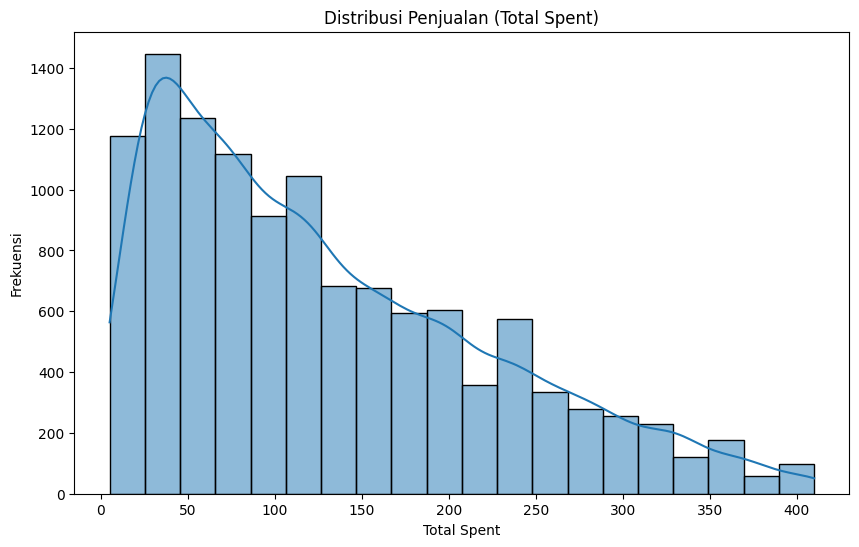

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Total Spent'], bins=20, kde=True)
plt.title('Distribusi Penjualan (Total Spent)')
plt.xlabel('Total Spent')
plt.ylabel('Frekuensi')
plt.show()

Dari Visualisasi data menunjukkan bahwa distribusi nilai Total Spent condong ke kanan (right-skewed), yang ditandai dengan ekor panjang pada sisi nilai yang lebih tinggi. Hal ini berarti sebagian besar transaksi memiliki nilai rendah hingga menengah, sementara hanya sedikit transaksi yang bernilai sangat tinggi. Keberadaan transaksi bernilai besar tersebut berpotensi menarik rata-rata ke atas dan memengaruhi interpretasi data jika hanya menggunakan mean sebagai ukuran pemusatan.

## **Relationship/Hubungan**

Aktivitas: Menganalisis hubungan antara kuantitas (Quantity) dengan pemberian diskon (Discount Applied).

Tujuan: Mengetahui apakah pemberian diskon efektif untuk meningkatkan total kuantitas produk yang dibeli oleh customer, serta mengidentifikasi apakah dengan pemberian diskon memberikan  keuntungan atau kerugian.

Visualisasi: Heatmap

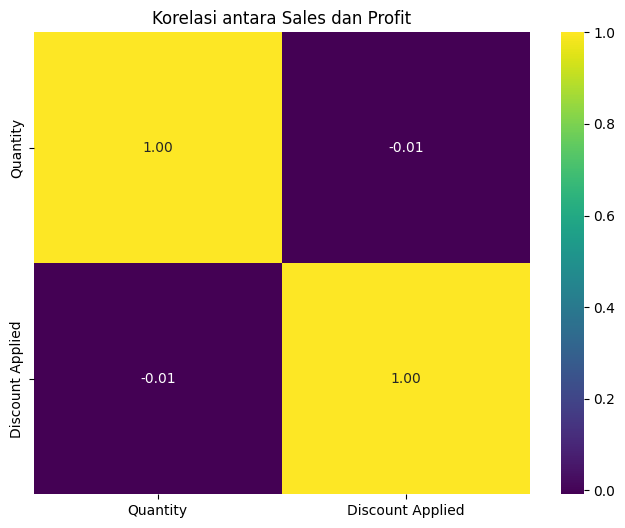

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(data=df[['Quantity', 'Discount Applied']].corr(),
            annot=True,
            cmap='viridis',
            fmt='.2f')
plt.title('Korelasi antara Sales dan Profit')
plt.show()

Dari Visualisasi data hasil ini menunjukkan bahwa perusahaan perlu mengevaluasi kembali strategi promosi berbasis diskon. Bisa jadi pelanggan membeli dalam jumlah yang sama baik ada diskon maupun tidak, sehingga diskon hanya mengurangi margin tanpa memberikan peningkatan kuantitas yang berarti. Strategi alternatif seperti bundling produk atau loyalty program mungkin lebih efektif dalam mendorong peningkatan pembelian.

# **Data Preparation**

Pada tahap ini, data diproses dengan cara membersihkan dan mengubah data mentah menjadi format yang siap dianalisis.

## **Inconsistent Values**

Pada tahap ini, kita akan menangani data yang tidak konsisten dan tipe data yang tidak sesuai, yang telah kita temukan pada tahap verifikasi kualitas data.

1. Menangani Tipe Data dari Kolom "Transaction Date"

Berikut data sebelum ditangani

In [ ]:
df['Transaction Date'].unique()

array(['2024-04-08', '2023-07-23', '2022-10-05', ..., '2023-03-17',
       '2024-02-29', '2022-09-16'], dtype=object)

Berikut data setelah ditangani

In [ ]:
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], format="mixed")
df["Transaction Date"].head(5)

,Transaction Date
0,2024-04-08
1,2023-07-23
2,2022-10-05
3,2022-05-07
4,2022-10-02


Disini saya sudah mengganti tipe data dari kolom Transaction Date yang semula object menjadi datetime. Hal ini dilakukan agar saat kita menganalisa, kolom Transaction Date dapat digunakan untuk melihat frekuensi atau tren, bukan menjadi objek.



2. Menangani Tipe Data dari Kolom "Quantity"

Berikut data sebelum ditangani

In [ ]:
df['Quantity'].unique()

array([10.,  9.,  2.,  7.,  8., nan,  1.,  3.,  6.,  4.,  5.])

Berikut data setelah ditangani

In [ ]:
df['Quantity'] = df['Quantity'].astype('Int64')
df['Quantity'].head(5)

,Quantity
0,10
1,9
2,2
3,9
4,7


Disini saya sudah mengganti tipe data dari kolom Quantity yang semula float64 menjadi int64. Hal ini dilakukan karena kuantitas atau jumlah barang tidak mungkin berjumlah desimal, karena dihitung per produk.

Untuk inconsistent values. Setelah menganalisis dari seluruh kolom, tidak ditemukan inkonsistensi data pada dataset ini, sehingga tidak ada yang perlu kita tangani.

## **Missing Values**

Pada tahap ini kita akan menangani data yang hilang. Jika data yang hilang >= 70% maka akan dihapus, dan <= 70% maka akan diimputasi.

Namun hal ini tidak dapat menjadi acuan tanpa adanya pemahaman mengenai tujuan dari kolom yang memiliki missing values tersebut dan informasi apa yang ingin kita dapatkan dari dataset ini.

In [ ]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
Transaction ID,0.000000
Customer ID,0.000000
Category,0.000000
Item,9.646123
Price Per Unit,4.842942
Quantity,4.803181
Total Spent,4.803181
Payment Method,0.000000
Location,0.000000
Transaction Date,0.000000


1. Item

Pada kolom ini memiliki presentasi hilangnya data sebesar 9,6% hal ini masih dibawah 70%. Kolom ini berfungsi sebagai wadah untuk menyimpan id unik tiap produk yang ditandai seperti "Item_17_MILK" yang berarti kolom ini berpengaruh dalam menandai setiap produk yang dijual. Namun dalam hal analisis, kolom ini tidak diperlukan karena tidak mendukung dalam proses analisis dan pengambilan keputusan. Keputusan yang kita ambil adalah menghapus kolom ini

In [ ]:
df = df.drop('Item', axis=1)

2. Price Per Unit

Pada kolom ini memiliki persentase missing values sebesar 4,8%, sehingga masih dapat untuk dilakukan imputasi. Kolom ini berfungsi sebagai nilai harga satuan dari setiap produk dan menjadi komponen utama dalam perhitungan total transaksi. Artinya, kolom ini sangat berpengaruh dalam analisis pendapatan, profitabilitas, serta evaluasi performa penjualan.

Jika baris dengan missing value dihapus, maka akan menyebabkan hilangnya informasi transaksi yang berpotensi penting. Oleh karena itu, keputusan yang diambil adalah melakukan imputasi menggunakan nilai median, karena median lebih tahan terhadap outlier dibandingkan mean dan lebih stabil dalam merepresentasikan harga yang wajar.

In [ ]:
df['Price Per Unit'] = df['Price Per Unit'].fillna(df['Price Per Unit'].dropna().median())

3. Total Spent

Pada kolom ini memiliki persentase missing values sebesar 4,8%, sehingga masih dapat untuk dilakukan imputasi. Kolom ini berfungsi sebagai total pengeluaran pelanggan dalam satu transaksi.

Jika baris dengan missing value dihapus, maka akan menyebabkan hilangnya informasi pendapatan yang penting. Oleh karena itu, keputusan yang diambil adalah melakukan imputasi menggunakan nilai median, karena data yang ditampilkan pada EDA adalah condong ke kanan.

In [ ]:
df['Total Spent'] = df['Total Spent'].fillna(df['Total Spent'].dropna().median())

4. Discount Applied

Pada kolom ini memiliki persentase missing values sebesar 33,3%, sehingga masih dapat untuk dilakukan imputasi.

Keputusan yang dapat kita ambil adalah modus. Penggunaan mean atau median tidak dapat diterapkan karena data bukan numerik. Dengan demikian, keputusan yang diambil adalah mengisi missing values pada kolom Discount Applied menggunakan nilai modus, karena metode ini paling sesuai untuk data kategorikal dan menjaga konsistensi distribusi data.

In [ ]:
df['Discount Applied'] = df['Discount Applied'].fillna(df['Discount Applied'].dropna().mode()[0])

5. Mengecek Kembali Missing Values

In [ ]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
Transaction ID,0.000000
Customer ID,0.000000
Category,0.000000
Price Per Unit,0.000000
Quantity,4.803181
Total Spent,0.000000
Payment Method,0.000000
Location,0.000000
Transaction Date,0.000000
Discount Applied,0.000000


Setelah menangani missing values, dapat dilihat bahwa dataset ini tidak memiliki missing values.

## **Duplicated Values**

Pada tahap ini kita menangani data yang terduplikat dengan drop/menghapus. Namun dikarenakan dataset ini tidak memiliki duplicated data, jadi tidak perlu ditangani.

## **Outliers Values**

Pada tahap ini, kita akan menangani nilai ekstrim yang ada pada dataset ini. Outliers yang ada bisa terjadi oleh banyak faktor dan tidak semua outliers perlu ditangani tergantung dari kasus yang ada.

In [ ]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
Price Per Unit,0.000000
Quantity,0.000000
Total Spent,0.477137


1. Menangani Kolom Quantity

Boxplot Outliers Quantity

Kolom,Persentase Outliers
Price Per Unit,0.000000
Quantity,0.031809
Total Spent,1.248509


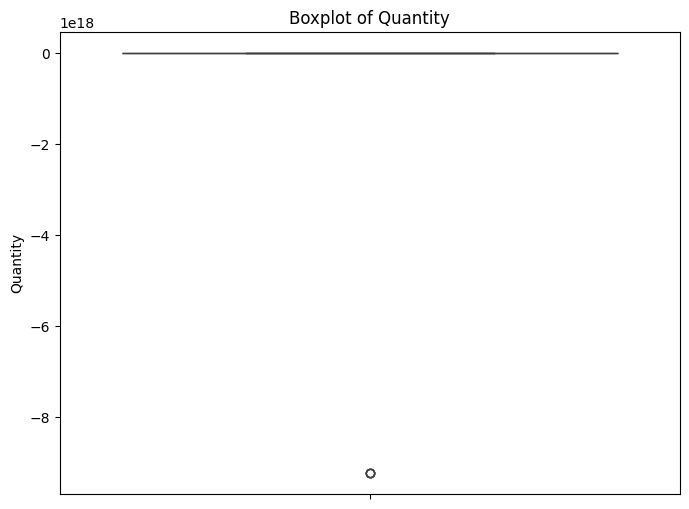

In [ ]:
na_index = df_temp[df_temp['Quantity'].isna()].index

if len(na_index) > 0:
    first_na_idx = na_index[0]
    df_temp.loc[first_na_idx, 'Quantity'] = -9223372036854775808
else:
    print("Tidak ada nilai NA di kolom Quantity.")

results_after_reinsert = []

cols_after_reinsert = df_temp.select_dtypes(include=['float64', 'int64'])

for col in cols_after_reinsert:
  q1 = df_temp[col].quantile(0.25)
  q3 = df_temp[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df_temp[(df_temp[col] < lower_bound) | (df_temp[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df_temp))*100
  results_after_reinsert.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df_after_reinsert = pd.DataFrame(results_after_reinsert)
results_df_after_reinsert.set_index('Kolom', inplace=True)
results_df_after_reinsert = results_df_after_reinsert.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df_after_reinsert)

# Tampilkan boxplot kolom Quantity
plt.figure(figsize=(8, 6))
sns.boxplot(y=df_temp['Quantity'])
plt.title('Boxplot of Quantity')
plt.ylabel('Quantity')
plt.show()

Mengecek baris mana yang memiliki outliers bernilai negatif.

In [ ]:
display(df_temp[df_temp['Quantity'] < 0])

,Transaction ID,Customer ID,Category,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
7,TXN_1372952,CUST_21,Furniture,33.5,-9223372036854775808,108.5,Digital Wallet,In-store,2024-04-02,True
15,TXN_1809665,CUST_14,Beverages,24.5,-9223372036854775808,108.5,Credit Card,In-store,2022-05-11,True
19,TXN_4206593,CUST_01,Furniture,35.0,-9223372036854775808,108.5,Digital Wallet,Online,2025-01-13,False


Disini terlihat bahwa isi dari kolom quantity yang bernilai negatif adalah -9223372036854775808 yang dimana nilai ini adalah nilai minimum dari tipe data int64. Sebelum kita ubah tipe data kolom quantity ke int64, kolom tersebut bertipe data float64. Outliers ini terjadi karna berkemungkinan kolom quantity berisikan missing values namun bertipe data int64, sehingga data yang ditampilkan bukan Nan namun nilai minimum.

Keputusan yang kita ambil adalah merubah nilai tersebut ke nan terlebih dahulu, lalu mengimputasinya menggunakan median.

In [ ]:
df.loc[df['Quantity'] == -9223372036854775808, 'Quantity'] = np.nan

In [ ]:
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())

Boxplot Kolom Quantity setelah ditangani

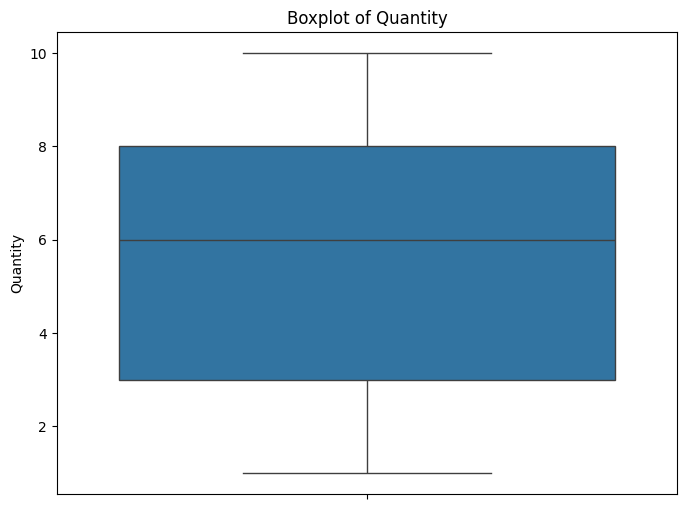

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Quantity'])
plt.title('Boxplot of Quantity')
plt.ylabel('Quantity')
plt.show()

2. Menangani Kolom Total Spent

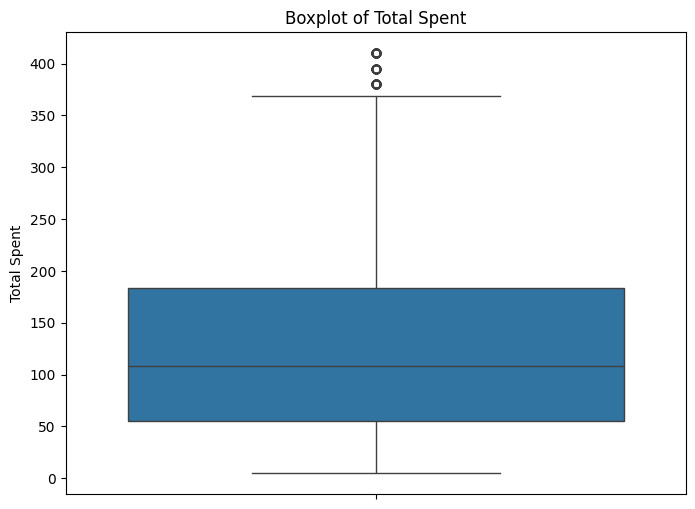

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Total Spent'])
plt.title('Boxplot of Total Spent')
plt.ylabel('Total Spent')
plt.show()

Dari visualisasi diatas, menunjukan outliers yang mendekati 0 dan 400+. Hal ini wajar karena setiap customer dapat membeli sedikit atau banyak barang, yang membuat total spent berbeda-beda. Hal ini tidak perlu ditangani.

# **Construct Data**

Pada tahap ini merupakan proses menambahkan sesuatu hal baru dari data yang sudah ada, tujuannya adalah untuk menambah insight atau memperkaya analisis. Namun dari studi kasus pada business objective, tidak diperlukan adanya penambahan kolom, dikarenakan kolom yang ada saat ini dapat melakukan analisis dan mencapai tujuan dari studi kasus.

# **Data Reduction**

Pada tahap ini, data reduction bertujuan untuk menyederhanakan dataset tanpa menghilangkan informasi penting. Data yang dibuang tergantung dari kasus atau tujuan kita menganalisa dataset ini.

Karena studi kasus kita yaitu

Sebuah perusahaan ritel ingin meningkatkan pendapatan dan memahami pola belanja pelanggan. Mereka mengumpulkan data transaksi untuk dianalisis agar tahu:

- Produk apa paling laku

- Kapan penjualan tinggi atau rendah

- Apakah diskon efektif

- Metode pembayaran favorit pelanggan



Maka kita akan menghapus kolom Transaction ID dan Customer ID tidak relevan terhadap studi kasus yang ada.

In [ ]:
df = df.drop('Transaction ID', axis=1)

In [ ]:
df = df.drop('Customer ID', axis=1)

# **Visualisasi Data**

Pada tahap ini, kita akan memvisualisasikan dari data yang telah kita tangani. Tujuan dari visualisasi data ini adalah, untuk mendapatkan insight yang akan membantu dalam proses pengambilan keputusan nantinya.

## **Menampilkan Dataset yang Telah Ditangani**

In [ ]:
file = "/content/drive/MyDrive/PRAKTIKUM AVD /retail_store_sales.csv"
df = pd.read_csv(file)

df

,Category,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,Patisserie,18.5,10,185.0,Digital Wallet,Online,2024-04-08,True
1,Milk Products,29.0,9,261.0,Digital Wallet,Online,2023-07-23,True
2,Butchers,21.5,2,43.0,Credit Card,Online,2022-10-05,False
3,Beverages,27.5,9,247.5,Credit Card,Online,2022-05-07,True
4,Food,12.5,7,87.5,Digital Wallet,Online,2022-10-02,False
...,...,...,...,...,...,...,...,...
12570,Patisserie,38.0,4,152.0,Credit Card,In-store,2023-09-03,True
12571,Beverages,6.5,9,58.5,Cash,Online,2022-08-12,False
12572,Butchers,14.0,10,140.0,Cash,Online,2024-08-24,True
12573,Furniture,14.0,6,84.0,Cash,Online,2023-12-30,True


## **Bar Chart**

### **Top 5 Kategori Produk dengan Jumlah Transaksi Terbanyak**

Tujuan dari visualisasi ini adalah, untuk mengetahui produk/kategori apa yang paling sering dibeli pelanggan sehingga perusahaan dapat memahami produk dengan permintaan tertinggi.

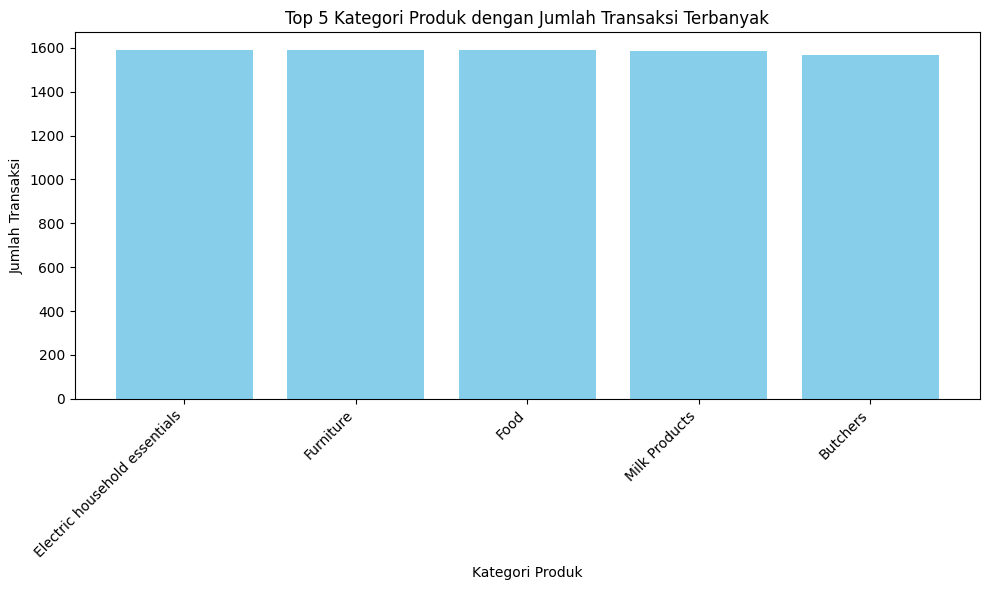

In [ ]:
VARIABEL = df['Category'].value_counts().head(5).sort_values(ascending=False) # head() jumlah yang mau ditampilkan & Urutan

plt.figure(figsize=(10, 6)) # Ukuran
plt.bar(VARIABEL.index, VARIABEL.values, color='skyblue') # color warna
plt.xlabel('Kategori Produk') # keterangan X label
plt.ylabel('Jumlah Transaksi') # keterangan y label
plt.title('Top 5 Kategori Produk dengan Jumlah Transaksi Terbanyak') # Judul
plt.xticks(rotation=45, ha='right') # rotasi teks
plt.tight_layout()
plt.show()

Berdasarkan visualisasi diatas, terdapat beberapa insight dan action yang dapat diambil:

**Insight**

Grafik menunjukkan bahwa jumlah transaksi antar kategori produk relatif seimbang. Tidak ada satu kategori yang mendominasi secara signifikan dalam jumlah transaksi. 5 Kategori tersebut memiliki jumlah transaksi yang hampir sama. Hal ini menunjukkan bahwa permintaan pelanggan tersebar cukup merata di berbagai kategori produk, sehingga pelanggan tidak hanya fokus pada satu jenis produk saja. Ini mengindikasikan bahwa toko memiliki portofolio produk yang cukup seimbang dalam menarik pelanggan.

**Action**

Perusahaan dapat melakukan beberapa strategi berikut:

1. Mempertahankan variasi produk di semua kategori. Semua kategori memiliki tingkat transaksi yang hampir sama, perusahaan sebaiknya tetap menjaga ketersediaan produk di seluruh kategori tersebut.

2. Menggunakan strategi cross-selling antar kategori. Pelanggan membeli berbagai jenis produk, perusahaan dapat membuat paket atau promosi seperti diskon pembelian produk makanan jika membeli produk kebutuhan rumah tangga.

3. Menentukan kategori unggulan untuk promosi. Perusahaan dapat memilih kategori tertentu untuk dijadikan produk unggulan promosi bulanan untuk meningkatkan penjualan lebih lanjut.

### **Efektivitas Diskon terhadap Total Belanja**

Tujuan dari visualisasi ini adalah, untuk menganalisis apakah pemberian diskon berpengaruh terhadap jumlah total belanja pelanggan. Dengan membandingkan transaksi yang menggunakan diskon dan yang tidak menggunakan diskon, kita dapat melihat apakah diskon benar-benar meningkatkan nilai pembelian pelanggan.

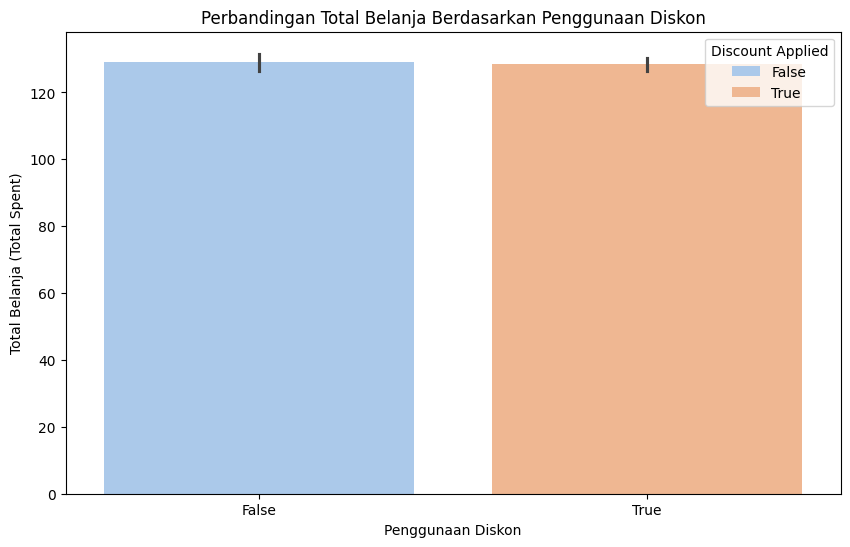

In [31]:
VARIABEL1 = df['Discount Applied'].value_counts().sort_values(ascending=False)
VARIABEL2 = df[df['Discount Applied'].isin(VARIABEL1.index)]

plt.figure(figsize=(10, 6)) # Ukuran
sns.barplot(x='Discount Applied', y='Total Spent', data=VARIABEL2, hue='Discount Applied', palette='pastel')
plt.title('Perbandingan Total Belanja Berdasarkan Penggunaan Diskon') # Judul
plt.xlabel('Penggunaan Diskon') # Keterangan X
plt.ylabel('Total Belanja (Total Spent)') # Keterangan Y
plt.xticks(rotation=0)
plt.show()

Berdasarkan visualisasi diatas, terdapat beberapa insight dan action yang dapat diambil:

**Insight**

Total belanja dengan dan tanpa diskon hampir sama. Pada grafik terlihat bahwa transaksi dengan diskon dan tanpa diskon memiliki perbedaan yang sangat kecil dan hampir tidak signifikan.

Artinya, pelanggan tidak meningkatkan nilai belanja mereka secara signifikan meskipun ada diskon. Dengan kata lain, diskon tidak terlalu mempengaruhi total pengeluaran pelanggan dalam satu transaksi.

**Action**

Perusahaan dapat melakukan beberapa strategi berikut:

1. Ubah strategi diskon menjadi diskon berbasis minimum pembelian. Karena diskon tidak meningkatkan total belanja, perusahaan bisa membuat syarat seperti diskon 10% minimal belanja 200 atau cashback pembelian di atas 150. Tujuannya untuk mendorong pelanggan meningkatkan nilai transaksi.

2. Gunakan bundling produk. Daripada diskon langsung, perusahaan bisa membuat paket seperti paket kebutuhan dapur dan paket produk rumah tangga. Bundling lebih efektif untuk menaikkan total pembelian.

3. Fokus diskon pada produk tertentu saja. Jika diskon diberikan ke semua produk, margin bisa turun tanpa meningkatkan penjualan. Strategi yang lebih baik yaitu seperti diskon pada produk slow moving atau diskon untuk produk promosi musiman.

## **Pie Chart**

Tujuan dari visualisasi ini adalah, untuk mengetahui metode pembayaran mana yang paling banyak digunakan pelanggan dalam menghasilkan total penjualan. Hal ini membantu perusahaan memahami preferensi pembayaran pelanggan dan menentukan strategi kerja sama dengan penyedia pembayaran.

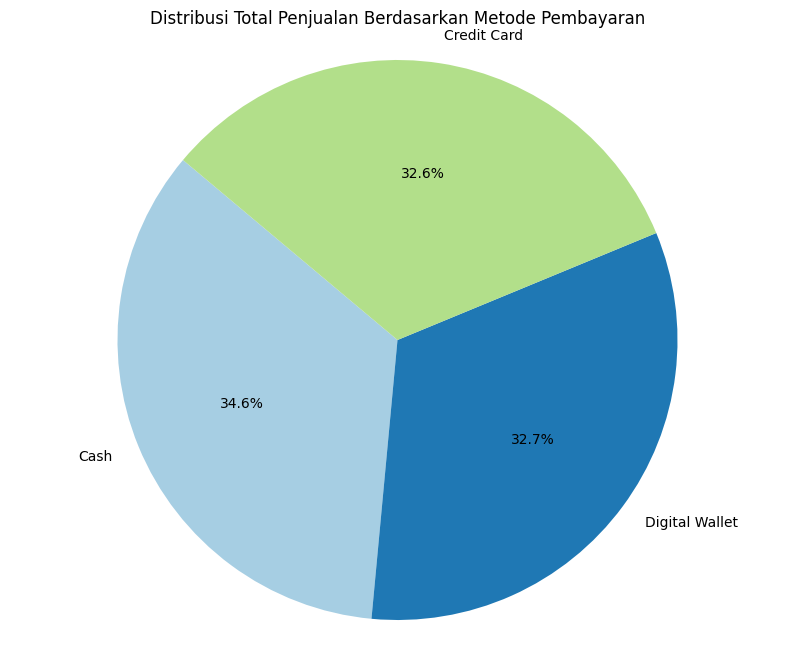

In [ ]:
VARIABEL1 = df.groupby('Payment Method')['Total Spent'].sum().sort_values(ascending=False)
VARIABEL2 = VARIABEL1.head(3)

plt.figure(figsize=(10, 8))
VARIABEL2.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)

plt.title('Distribusi Total Penjualan Berdasarkan Metode Pembayaran')
plt.ylabel('')
plt.axis('equal')

plt.show()

Berdasarkan visualisasi diatas, terdapat beberapa insight dan action yang dapat diambil:

**Insight**

Grafik menunjukkan bahwa metode pembayaran pelanggan cukup terdistribusi merata. Ini menunjukkan bahwa tidak ada metode pembayaran yang benar-benar dominan.

Namun terdapat satu insight penting yaitu **pembayaran digital (Credit Card + Digital Wallet) secara total menyumbang sekitar 65% transaksi.**

Artinya mayoritas pelanggan sudah lebih nyaman menggunakan pembayaran non-tunai.

**Action**

Perusahaan dapat melakukan beberapa strategi berikut:

1. Mengoptimalkan sistem pembayaran digital. Perusahaan dapat meningkatkan pengalaman pembayaran digital dengan mempercepat proses transaksi dan menambah opsi e-wallet lain

2. Membuat promo khusus pembayaran digital. Contohnya seperti cashback jika menggunakan e-wallet dan diskon pembayaran kartu kredit

Hal Ini bisa meningkatkan jumlah transaksi sekaligus kerja sama dengan penyedia pembayaran.

## **Line Chart**

Tujuan dari visualisasi ini adalah, untuk mengetahui tren jumlah transaksi penjualan dari waktu ke waktu sehingga perusahaan dapat memahami periode dengan aktivitas penjualan tinggi maupun rendah. Penggunaan visualisasi berdasarkan bulan memiliki alasan yaitu visualisasi bulanan memberikan analisis operasional yang jauh lebih detail. Perusahaan atau stakeholder bisa mengetahui bulan dengan penjualan tertinggi, bulan dengan penjualan terendah, dan pola musiman dalam perilaku belanja pelanggan.

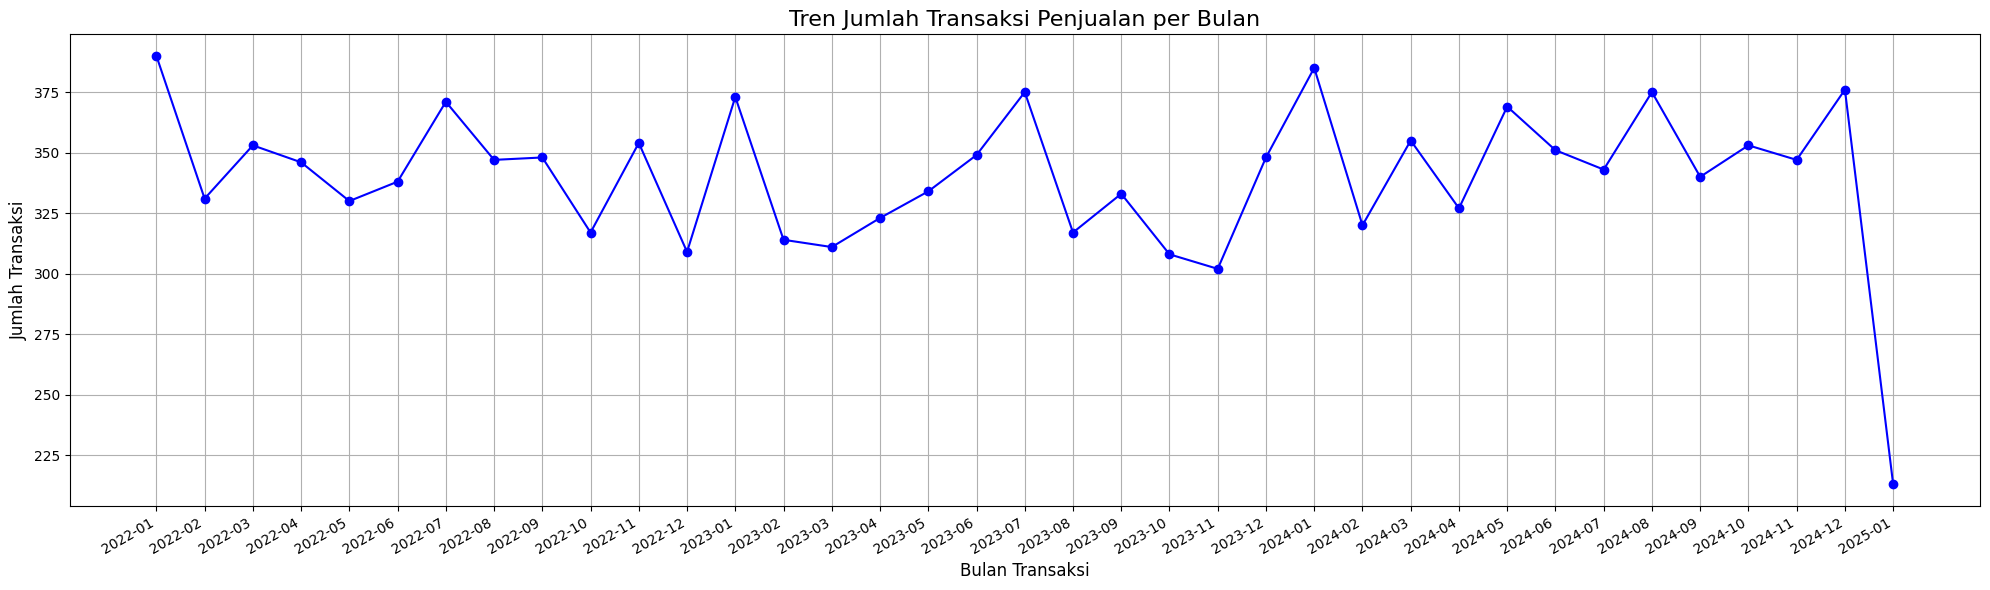

In [ ]:
# Pastikan kolom bertipe datetime
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

# Group by month
VARIABEL1 = df.groupby(df['Transaction Date'].dt.to_period('M')).size()

plt.figure(figsize=(20, 6))
plt.plot(VARIABEL1.index.astype(str), VARIABEL1.values, marker='o', color='blue')

plt.title('Tren Jumlah Transaksi Penjualan per Bulan', fontsize=16)
plt.xlabel('Bulan Transaksi', fontsize=12)
plt.ylabel('Jumlah Transaksi', fontsize=12)

plt.grid(True)
plt.gcf().autofmt_xdate()
plt.tight_layout()

plt.show()

Berdasarkan visualisasi diatas, terdapat beberapa insight dan action yang dapat diambil:

**Insight**

Grafik menunjukkan bahwa jumlah transaksi bulanan relatif stabil sepanjang waktu. Permintaan pelanggan cukup konsisten sepanjang tahun.

Namun terdapat beberapa bulan dengan kenaikan transaksi yang lebih tinggi, yang kemungkinan dipengaruhi oleh periode promosi, musim belanja, hari besar atau liburan. Stabilitas ini merupakan indikator bisnis yang sehat, karena menunjukkan bahwa toko memiliki basis pelanggan yang konsisten.

**Action**

Perusahaan dapat melakukan beberapa strategi berikut:

1. Mengidentifikasi bulan dengan penjualan tinggi. Perusahaan dapat mengevaluasi apakah pada bulan tersebut ada promosi, apakah terdapat event tertentu. Jika iya, strategi tersebut bisa diulang pada tahun berikutnya. Jika tidak, maka perlu dilakukan evaluasi.

2. Meningkatkan promosi pada bulan yang lebih rendah. Pulan dengan transaksi lebih rendah, perusahaan dapat memberikan diskon, membuat program loyalty atau mengadakan promo musiman

3. Perencanaan stok yang lebih akurat. Karena pola penjualan cukup stabil, perusahaan dapat melakukan pengadaan stok yang lebih akurat.

## **Histogram**

Tujuan dari visualisasi ini adalah, untuk mengetahui pola distribusi nilai transaksi pelanggan untuk memahami apakah mayoritas transaksi bernilai kecil atau banyak transaksi bernilai besar. Informasi ini membantu perusahaan memahami perilaku belanja pelanggan.

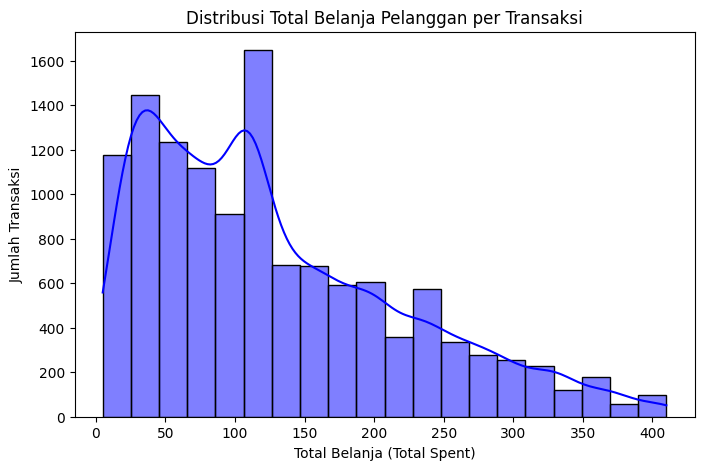

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Total Spent'], bins=20, kde=True, color='blue')

plt.title('Distribusi Total Belanja Pelanggan per Transaksi')
plt.xlabel('Total Belanja (Total Spent)')
plt.ylabel('Jumlah Transaksi')

plt.show()

Berdasarkan visualisasi diatas, terdapat beberapa insight dan action yang dapat diambil:

**Insight**

Histogram menunjukkan bahwa sebagian besar transaksi berada pada kisaran belanja rendah hingga menengah. Sebagian besar pelanggan melakukan transaksi sekitar 50 – 150 total belanja, sementara transaksi dengan nilai sangat tinggi jumlahnya jauh lebih sedikit. Ini menunjukkan bahwa mayoritas pelanggan melakukan pembelian kecil tetapi sering, bukan pembelian besar dalam satu transaksi.

**Action**

Perusahaan dapat melakukan beberapa strategi berikut:

1. Meningkatkan nilai rata-rata pembelian. Perusahaan dapat membuat strategi seperti diskon minimal belanja atau promo beli lebih banyak lebih murah. Contohnya seperti diskon 10% untuk pembelian di atas 200.

2. Membuat paket bundling produk. Produk dengan harga kecil dapat digabungkan menjadi paket untuk meningkatkan nilai transaksi.

3. Menargetkan pelanggan yang memiliki total spent tiggi. Pelanggan dengan transaksi besar dapat diberikan membership atau promo eksklusif.

## **Box Plot**

Tujuan dari visualisasi ini adalah, untuk mengetahui perbandingan nilai transaksi antar kategori produk yang bertujuan untuk memahami kategori produk dengan nilai transaksi rata-rata tinggi, kategori produk dengan variasi transaksi besar, serta adanya transaksi ekstrem (outliers) pada kategori tertentu.

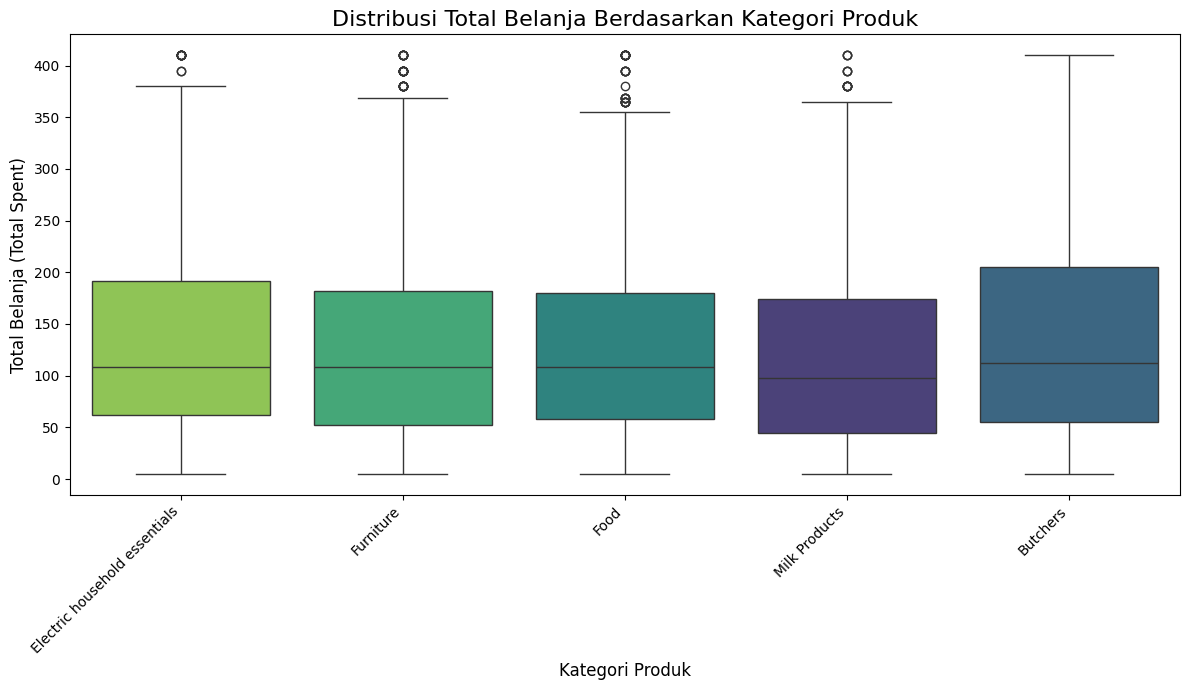

In [ ]:
VARIABEL1 = df['Category'].value_counts().head(5).index
VARIABEL2 = df[df['Category'].isin(VARIABEL1)]

plt.figure(figsize=(12, 7))
sns.boxplot(x='Category', y='Total Spent', data=VARIABEL2, palette='viridis', order=VARIABEL1, hue='Category', legend=False)

plt.title('Distribusi Total Belanja Berdasarkan Kategori Produk', fontsize=16)
plt.xlabel('Kategori Produk', fontsize=12)
plt.ylabel('Total Belanja (Total Spent)', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Berdasarkan visualisasi diatas, terdapat beberapa insight dan action yang dapat diambil:

**Insight**

Grafik menunjukkan bahwa nilai transaksi antar kategori produk cukup mirip, tetapi terdapat outlier transaksi yang cukup tinggi pada beberapa kategori. Hal ini berarti sebagian besar transaksi memiliki nilai normal, tetapi ada beberapa pelanggan yang melakukan pembelian dalam jumlah besar.

Kategori seperti Butchers atau Electric household essentials tampak memiliki beberapa transaksi dengan nilai sangat tinggi.

Ini menunjukkan adanya pembelian dalam jumlah besar pada kategori tertentu.

**Action**

Perusahaan dapat melakukan beberapa strategi berikut:

1. Mengidentifikasi produk yang sering dibeli dalam jumlah besar yang dimana produk tersebut dapat dijadikan produk unggulan atau paket grosir.

2. Menyediakan diskon pembelian besar. Contohnya seperti diskon khusus pembelian produk daging dalam jumlah tertentu.

3. Menargetkan pelanggan dengan pembelian besar. Perusahaan dapat membuat program pelanggan loyal untuk pelanggan yang sering melakukan transaksi besar.

## **Scatter Plot**

Tujuan dari visualisasi ini adalah, untuk menganalisis hubungan antara harga produk dan total nilai transaksi pelanggan. Dengan scatter plot ini, perusahaan dapat memahami apakah transaksi dengan nilai tinggi berasal dari produk mahal atau berasal dari pembelian banyak produk dengan harga lebih murah. Analisis ini membantu perusahaan memahami bagaimana harga produk mempengaruhi nilai transaksi pelanggan.

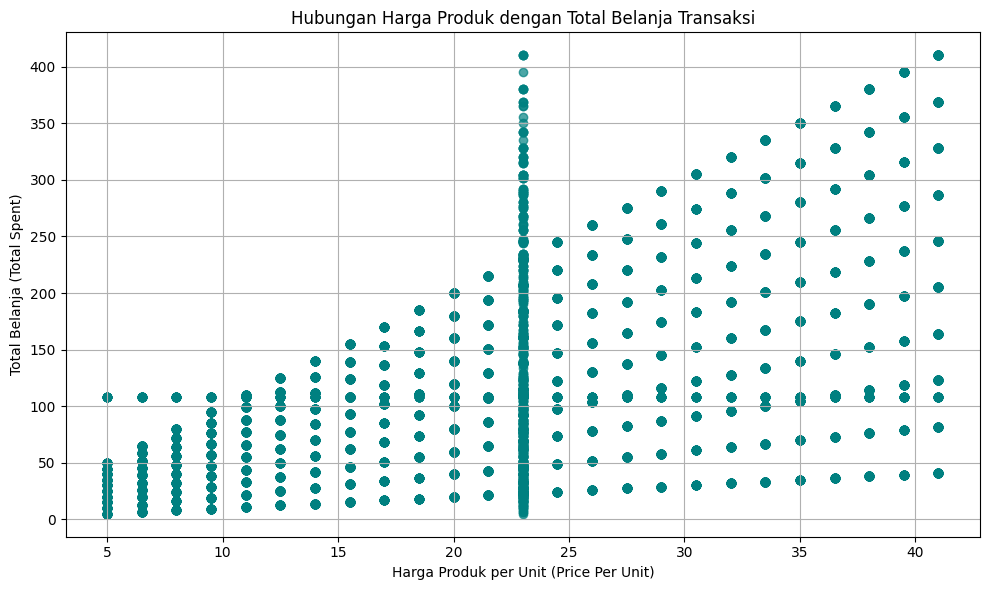

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Price Per Unit'], df['Total Spent'], alpha=0.7, color='teal')

plt.title('Hubungan Harga Produk dengan Total Belanja Transaksi')
plt.xlabel('Harga Produk per Unit (Price Per Unit)')
plt.ylabel('Total Belanja (Total Spent)')

plt.grid(True)
plt.tight_layout()
plt.show()

Berdasarkan visualisasi diatas, terdapat beberapa insight dan action yang dapat diambil:

**Insight**

Scatter plot menunjukkan bahwa total belanja meningkat seiring dengan kenaikan harga produk. Namun terlihat juga bahwa produk mahal biasanya dibeli dalam jumlah lebih sedikit dan produk murah dibeli dalam jumlah lebih banyak.

Hal Ini menunjukkan dua tipe perilaku pelanggan:

1. Pelanggan membeli banyak produk murah
2. Pelanggan membeli sedikit produk mahal

Kedua pola ini sama-sama berkontribusi pada pendapatan toko.

**Action**

Perusahaan dapat melakukan beberapa strategi berikut:

1. Mengoptimalkan produk murah sebagai pengendali pelanggan. Produk murah bisa menarik pelanggan untuk datang ke toko.

2. Mengembangkan strategi produk premium. Produk mahal dapat dipromosikan sebagai produk premium dengan margin tinggi.

3. Strategi bundling. Menggabungkan produk mahal dengan produk tambahan dapat meningkatkan nilai transaksi.

## **Bubble Chart**

Tujuan dari visualisasi ini adalah, untuk memahami hubungan antara harga produk, total nilai transaksi, jumlah produk yang dibeli, kategori produk. Analisis ini membantu perusahaan agar dapat melihat pola pembelian pelanggan berdasarkan jenis produk dan nilai transaksi.

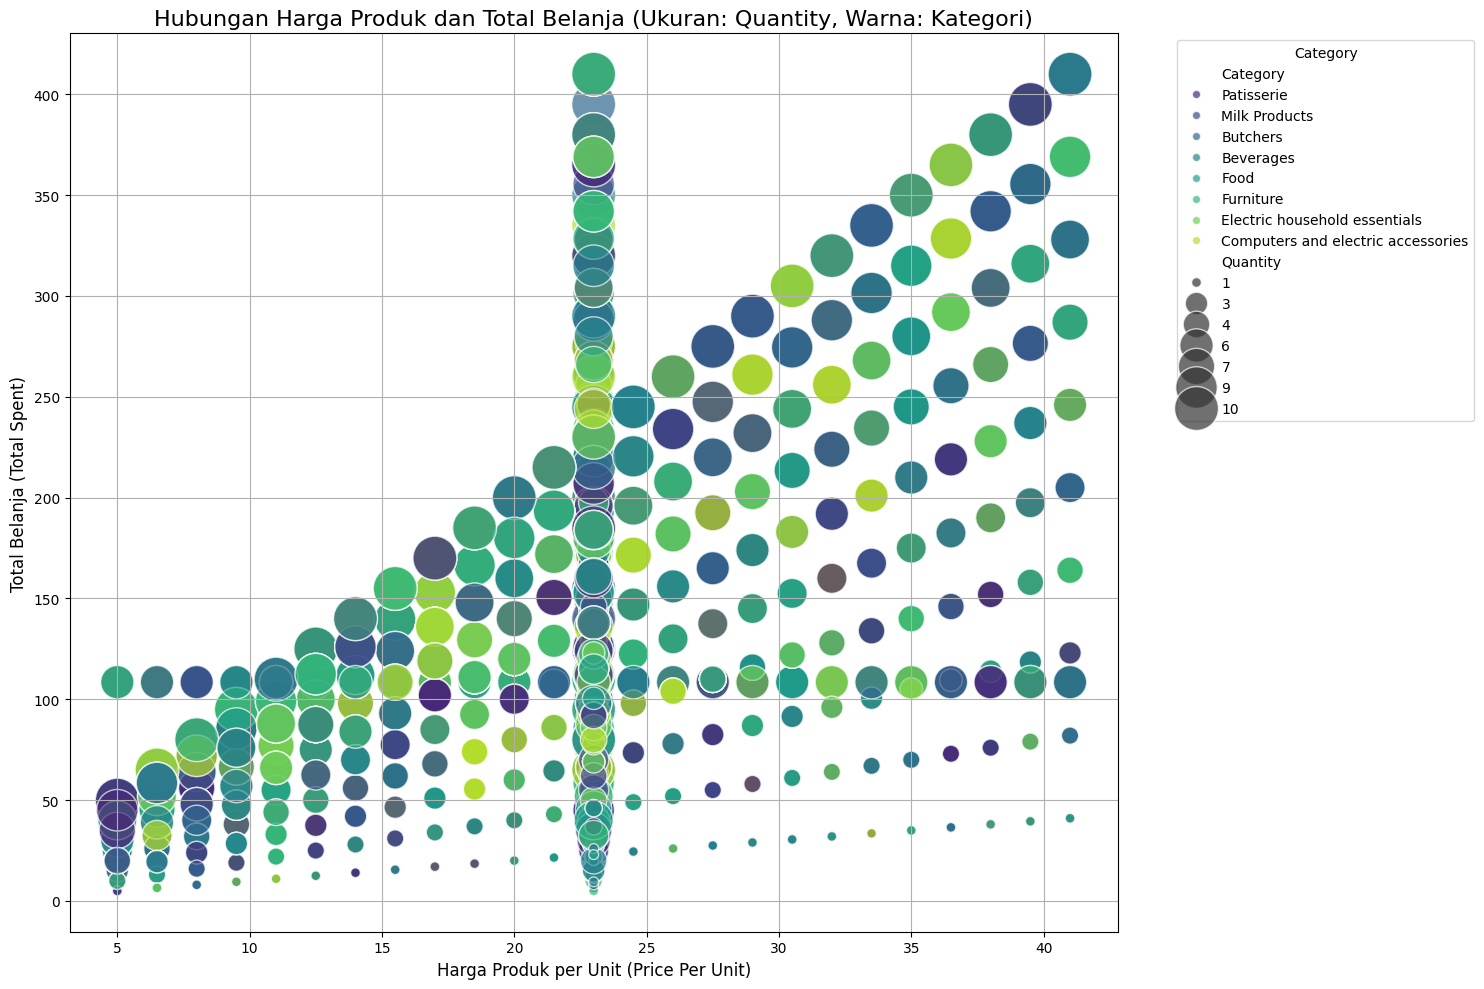

In [ ]:
plt.figure(figsize=(15, 10))

sns.scatterplot(
    x='Price Per Unit',
    y='Total Spent',
    size='Quantity',
    hue='Category',
    data=df,
    sizes=(50, 1000),
    alpha=0.7,
    palette='viridis'
)

plt.title('Hubungan Harga Produk dan Total Belanja (Ukuran: Quantity, Warna: Kategori)', fontsize=16)
plt.xlabel('Harga Produk per Unit (Price Per Unit)', fontsize=12)
plt.ylabel('Total Belanja (Total Spent)', fontsize=12)

plt.grid(True)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

Berdasarkan visualisasi diatas, terdapat beberapa insight dan action yang dapat diambil:

**Insight**

Bubble chart memperlihatkan pola yang lebih kompleks yaitu:

1. bubble besar banyak muncul pada harga rendah

2. bubble kecil sering muncul pada harga tinggi

Ini menandakan bahwa produk murah sering dibeli dalam jumlah besar dan produk mahal biasanya dibeli dalam jumlah kecil

Selain itu terlihat bahwa beberapa kategori produk muncul pada transaksi bernilai tinggi, yang menunjukkan kontribusi besar terhadap pendapatan.

**Action**

Perusahaan dapat melakukan beberapa strategi berikut:

1. Memaksimalkan penjualan produk volume tinggi. Produk murah dapat digunakan sebagai produk promosi utama.

2. Menonjolkan produk mahal sebagai produk premium. Produk mahal dapat ditempatkan pada display utama toko.

3. Strategi segmentasi produk. Perusahaan dapat membagi produk menjadi produk volume tinggi dan produk margin tinggi

## **Heat Map**

Tujuan dari visualisas ini adalah, untuk menganalisis hubungan antar variabel numerik dalam dataset transaksi ritel. Melalui heatmap ini, perusahaan dapat memahami variabel mana yang memiliki hubungan kuat atau variabel mana yang tidak terlalu mempengaruhi satu sama lain. Analisis ini membantu perusahaan dalam memahami faktor-faktor yang mempengaruhi nilai transaksi pelanggan.

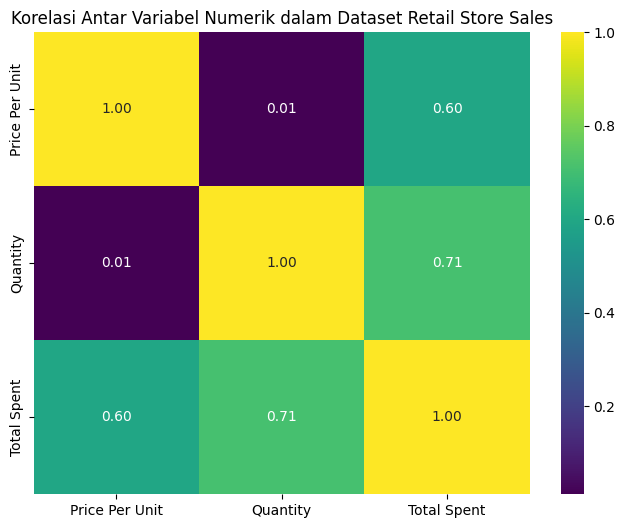

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    data=df[['Price Per Unit', 'Quantity', 'Total Spent']].corr(),
    annot=True,
    cmap='viridis',
    fmt='.2f'
)

plt.title('Korelasi Antar Variabel Numerik dalam Dataset Retail Store Sales')

plt.show()

Berdasarkan visualisasi diatas, terdapat beberapa insight dan action yang dapat diambil:

**Insight**

Heatmap menunjukkan beberapa hubungan penting seperti:

1. Quantity vs Total Spent = 0.71 (kuat)

2. Price vs Total Spent = 0.60 (cukup kuat)

3. Price vs Quantity = 0.01 (hampir tidak ada hubungan)

Artinya, nilai transaksi paling dipengaruhi oleh jumlah produk yang dibeli, bukan hanya harga produk.

Ini berarti strategi peningkatan penjualan sebaiknya fokus pada meningkatkan jumlah item dalam transaksi.

**Action**

Perusahaan dapat melakukan beberapa strategi berikut:

1. Mendorong pembelian lebih banyak produk. Strategi yang bisa dilakukan contohnya promo beli 2 gratis 1 atau diskon pembelian banyak.

2. Membuat paket produk. Bundling produk dapat meningkatkan jumlah item dalam transaksi.

3. Menyusun strategi promosi berbasis quantity. Promo yang menargetkan jumlah pembelian akan lebih efektif dibanding hanya menurunkan harga produk.

# **Menyimpan Dataset**

In [ ]:
output_path = "/content/drive/MyDrive/PRAKTIKUM AVD /retail_store_sales.csv"

df.to_csv(output_path, index=False)
print(f"file tersimpan di {output_path}")

file tersimpan di /content/drive/MyDrive/PRAKTIKUM AVD /retail_store_sales.csv
